## Resume ↔ Job Description Matching

Recruiters spend an average of **7.4 seconds** reviewing each resume ([Ladders, 2018](https://www.theladders.com/static/images/basicSite/pdfs/TheLadders-EyeTracking-StudyC2.pdf)), so qualified candidates are routinely missed at scale. This project builds and compares automated scoring systems that predict how well a resume matches a job description.

We benchmark three approaches of increasing sophistication against the ground-truth `matched_score` in the [Resume Dataset](https://www.kaggle.com/datasets/saugataroyarghya/resume-dataset/data) from Kaggle. Each row in the dataset contains a resume, a job description, and a `matched_score` quantifying how well the resume matches the JD.

| # | Method | Family | Supervised? |
|---|--------|--------|-------------|
| 1 | **TF-IDF + cosine similarity** — sparse lexical baseline. Fast and interpretable, but blind to paraphrase. | Lexical | No |
| 2 | **SBERT bi-encoder + cosine similarity** — dense semantic baseline (`all-MiniLM-L6-v2`). Each side encoded independently; captures meaning beyond word overlap. | Dense | No |
| 3 | **Fine-tuned cross-encoder** — supervised pair model (`ms-marco-MiniLM-L-6-v2`) trained directly on `matched_score` with MSE loss. Attends jointly across both texts. | Pair model | **Yes** |

All three are evaluated on the same test set using regression metrics (Pearson, Spearman, MAE, RMSE) and ranking metrics (NDCG@10, Precision@10, MRR).

**Runtime:** ~25–35 min on a Colab T4 (mostly Section 9 training). CPU fallback works but is slow.

**Before running:** set the runtime to GPU (`Runtime → Change runtime type → T4 GPU`), then upload your CSV when prompted in Section 3 (or set `DATA_PATH` directly).

## 1. Install dependencies

In [ ]:
# Pin to versions known to work with the v4+ CrossEncoderTrainer API
%pip install -q "sentence-transformers>=4.0" "transformers>=4.41" "datasets>=2.19" \
    scikit-learn scipy pandas matplotlib seaborn nltk

## 2. Imports and environment check

In [ ]:
import os, ast, re, hashlib, warnings, random
from pathlib import Path
from typing import Iterable, Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_absolute_error, mean_squared_error, ndcg_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr, spearmanr

import nltk
for pkg in ("stopwords", "wordnet", "omw-1.4"):
    nltk.download(pkg, quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device:       {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU:          {torch.cuda.get_device_name(0)}")
    print(f"VRAM:         {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING:      No GPU detected. Section 9 training will be slow on CPU.")
print(f"PyTorch:      {torch.__version__}")

Device:       cuda
GPU:          Tesla T4
VRAM:         15.6 GB
PyTorch:      2.10.0+cu128


## 3. Configuration

All knobs in one place. Adjust `DATA_PATH` to point at your CSV.


In [ ]:
from google.colab import drive
import os


drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/NLP Group Project/')


print("Current directory:", os.getcwd())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Current directory: /content/drive/MyDrive/NLP Group Project


In [ ]:
ls

datasets/  notebooks/  report/


In [ ]:
# ----- Data -----
DATA_PATH = "datasets/resume_data.csv"   # change me, or upload via the Files pane

# ----- TF-IDF -----
TFIDF_NGRAM_RANGE = (1, 2)
TFIDF_MIN_DF      = 2
TFIDF_MAX_DF      = 0.95
TFIDF_MAX_FEAT    = 30_000

# ----- Embeddings -----
EMBEDDING_MODEL    = "sentence-transformers/all-MiniLM-L6-v2"
EMBED_BATCH_SIZE   = 64

# ----- Cross-encoder -----
CE_BASE_MODEL = "cross-encoder/ms-marco-MiniLM-L-6-v2"
CE_MAX_LEN    = 384
CE_EPOCHS     = 3
CE_BATCH_SIZE = 16
CE_LR         = 2e-5
CE_OUTPUT_DIR = "outputs/models/cross_encoder_resume_jd"

# ----- Ranking eval -----
TOP_K              = 10
RELEVANCE_QUANTILE = 0.5   # binarise matched_score at this quantile

# ----- Output dirs -----
for d in ["outputs", "outputs/figures", "outputs/metrics", "outputs/models"]:
    Path(d).mkdir(parents=True, exist_ok=True)

## 4. Helper functions

### 4.1 Text preprocessing

In [ ]:
_STOPWORDS    = set(stopwords.words("english"))
_LEMMATIZER   = WordNetLemmatizer()
_URL_PATTERN  = re.compile(r"http\S+|www\.\S+")
_NONALPHA     = re.compile(r"[^a-z0-9+#./\- ]")
_WS           = re.compile(r"\s+")

def clean_text(text: str) -> str:
    """Lowercase, drop URLs, keep tech-y punctuation (+, #, ., /, -), lemmatise, drop stopwords."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = _URL_PATTERN.sub(" ", text)
    text = _NONALPHA.sub(" ", text)
    text = _WS.sub(" ", text).strip()
    tokens = [_LEMMATIZER.lemmatize(t) for t in text.split()
              if t not in _STOPWORDS and len(t) > 1]
    return " ".join(tokens)

### 4.2 List-field parsing and composite text builder

In [ ]:
def parse_list_string(raw) -> list[str]:
    """Parse a stringified list like "['Python', 'Docker']" into a plain list."""
    if pd.isna(raw):
        return []
    if isinstance(raw, list):
        return [str(x) for x in raw]
    if not isinstance(raw, str):
        return [str(raw)]
    s = raw.strip()
    if not s:
        return []
    if s.startswith("["):
        try:
            parsed = ast.literal_eval(s)
        except Exception:
            return [s.strip("[]").replace("'", "").replace('"', "")]
        flat: list[str] = []
        def _flatten(x):
            if isinstance(x, (list, tuple, set)):
                for item in x: _flatten(item)
            elif x is not None:
                flat.append(str(x))
        _flatten(parsed)
        return flat
    return [s]


def build_composite_text(df: pd.DataFrame, fields: Sequence[str],
                         list_fields: set[str]) -> pd.Series:
    """Concatenate the given columns into one string per row.
    List-typed fields are parsed and space-joined first."""
    def row_to_text(row):
        parts = []
        for col in fields:
            if col not in row.index:
                continue
            val = row[col]
            if col in list_fields:
                parts.extend(parse_list_string(val))
            elif pd.notna(val):
                parts.append(str(val))
        return " . ".join(p for p in parts if p)
    return df.apply(row_to_text, axis=1)

### 4.3 TF-IDF scorer

In [ ]:
def score_lexical(resumes: list[str], jobs: list[str]):
    """Fit TF-IDF on resumes+jobs, return per-row cosine similarity."""
    vec = TfidfVectorizer(
        ngram_range = TFIDF_NGRAM_RANGE,
        min_df      = TFIDF_MIN_DF,
        max_df      = TFIDF_MAX_DF,
        max_features= TFIDF_MAX_FEAT,
        sublinear_tf= True,
    )
    vec.fit(resumes + jobs)
    R = vec.transform(resumes)
    J = vec.transform(jobs)

    # Row-wise cosine via diagonal of R @ J.T
    R_norm = R.multiply(1.0 / (np.sqrt(R.multiply(R).sum(axis=1)) + 1e-12))
    J_norm = J.multiply(1.0 / (np.sqrt(J.multiply(J).sum(axis=1)) + 1e-12))
    scores = np.asarray(R_norm.multiply(J_norm).sum(axis=1)).ravel()
    return scores, vec, R, J

### 4.4 Sentence embedding scorer (cached on disk)

In [ ]:
from sentence_transformers import SentenceTransformer

_SBERT = None
def _load_sbert():
    global _SBERT
    if _SBERT is None:
        _SBERT = SentenceTransformer(EMBEDDING_MODEL, device=DEVICE)
    return _SBERT

def embed_texts(texts: list[str], label: str = "default") -> np.ndarray:
    """L2-normalised embeddings, cached on disk by hash of inputs+model."""
    key = hashlib.md5(("||".join(texts) + EMBEDDING_MODEL).encode("utf-8")).hexdigest()
    cache = Path(f"outputs/cache_emb_{label}_{key[:8]}.npy")
    cache.parent.mkdir(parents=True, exist_ok=True)
    if cache.exists():
        return np.load(cache)
    model = _load_sbert()
    emb = model.encode(texts, batch_size=EMBED_BATCH_SIZE, convert_to_numpy=True,
                       normalize_embeddings=True, show_progress_bar=True)
    np.save(cache, emb)
    return emb

### 4.5 Evaluation: regression + ranking

In [ ]:
def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    pearson,  _ = pearsonr(y_true, y_pred)
    spearman, _ = spearmanr(y_true, y_pred)
    return {
        "MAE":          float(mean_absolute_error(y_true, y_pred)),
        "RMSE":         float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "Pearson r":    float(pearson),
        "Spearman rho": float(spearman),
    }


def ranking_metrics(df_in: pd.DataFrame, pred_col: str, k: int = None,
                    rel_quantile: float = None) -> dict:
    """For every JD group with >=2 resumes, rank by pred_col and score the ordering.

    - NDCG@k uses raw matched_score as graded relevance.
    - Precision@k binarises matched_score at the global quantile threshold.
    - MRR uses the same binary relevance.
    """
    k = k or TOP_K
    rel_quantile = rel_quantile if rel_quantile is not None else RELEVANCE_QUANTILE
    threshold = df_in["matched_score"].quantile(rel_quantile)

    ndcgs, precs, rrs = [], [], []
    n_groups = 0
    for _, grp in df_in.groupby("jd_group"):
        if len(grp) < 2:
            continue
        n_groups += 1
        y_true = grp["matched_score"].to_numpy()
        y_pred = grp[pred_col].to_numpy()
        # NDCG
        ndcgs.append(ndcg_score([y_true], [y_pred], k=min(k, len(grp))))
        # Binary relevance for prec@k and MRR
        rel = (y_true >= threshold).astype(int)
        order = np.argsort(-y_pred)
        top   = order[:k]
        precs.append(rel[top].sum() / min(k, len(grp)))
        # MRR: rank of first relevant item
        ranked_rel = rel[order]
        if ranked_rel.sum() == 0:
            rrs.append(0.0)
        else:
            rrs.append(1.0 / (np.argmax(ranked_rel) + 1))

    if n_groups == 0:
        return {"n_groups_evaluated": 0, "relevance_threshold": float(threshold)}
    return {
        "n_groups_evaluated":  n_groups,
        "relevance_threshold": float(threshold),
        f"NDCG@{k}":           float(np.mean(ndcgs)),
        f"Precision@{k}":      float(np.mean(precs)),
        "MRR":                 float(np.mean(rrs)),
    }

### 4.6 Explainability — top shared TF-IDF terms

In [ ]:
def top_shared_terms(vectorizer, r_vec, j_vec, k: int = 8) -> list[tuple[str, float]]:
    """Per-pair: terms where both vectors have non-zero TF-IDF, ranked by product of weights."""
    feat_names = np.asarray(vectorizer.get_feature_names_out())
    r = r_vec.toarray().ravel()
    j = j_vec.toarray().ravel()
    contrib = r * j
    nz = np.nonzero(contrib)[0]
    if len(nz) == 0:
        return []
    top = nz[np.argsort(-contrib[nz])][:k]
    return [(feat_names[i], float(contrib[i])) for i in top]

## 5. Load data



In [ ]:
df = pd.read_csv(DATA_PATH, encoding_errors="replace")
df.columns = [c.lstrip("\ufeff").strip() for c in df.columns]  # strip BOM/whitespace

print(f"Shape: {df.shape}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head(2)

Shape: (9544, 35)
Memory: 30.8 MB


,address,career_objective,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,professional_company_names,...,online_links,issue_dates,expiry_dates,job_position_name,educationaL_requirements,experiencere_requirement,age_requirement,responsibilities.1,skills_required,matched_score
0,NaN,Big data analytics working and database wareho...,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...",['The Amity School of Engineering & Technology...,['B.Tech'],['2019'],['N/A'],[None],['Electronics'],['Coca-COla'],...,NaN,NaN,NaN,Senior Software Engineer,B.Sc in Computer Science & Engineering from a ...,At least 1 year,NaN,Technical Support\nTroubleshooting\nCollaborat...,NaN,0.85
1,NaN,Fresher looking to join as a data analyst and ...,"['Data Analysis', 'Data Analytics', 'Business ...","['Delhi University - Hansraj College', 'Delhi ...","['B.Sc (Maths)', 'M.Sc (Science) (Statistics)']","['2015', '2018']","['N/A', 'N/A']","['N/A', 'N/A']","['Mathematics', 'Statistics']",['BIB Consultancy'],...,NaN,NaN,NaN,Machine Learning (ML) Engineer,M.Sc in Computer Science & Engineering or in a...,At least 5 year(s),NaN,Machine Learning Leadership\nCross-Functional ...,NaN,0.75


In [ ]:
# Schema overview - sparsity is the main thing to check
schema = pd.DataFrame({
    "dtype":    df.dtypes.astype(str),
    "n_unique": df.nunique(dropna=True),
    "pct_null": (df.isna().mean() * 100).round(1),
})
schema.sort_values("pct_null").head(15)

,dtype,n_unique,pct_null
educationaL_requirements,object,20,0.0
job_position_name,object,28,0.0
responsibilities,object,28,0.0
responsibilities.1,object,28,0.0
matched_score,float64,345,0.0
skills,object,340,0.6
educational_results,object,78,0.9
educational_institution_name,object,328,0.9
end_dates,object,246,0.9
related_skils_in_job,object,298,0.9


## 6. Build composite resume and JD texts

Resume side draws from: career objective, skills, responsibilities, positions, education major, certifications.
JD side: position name, skills required, responsibilities, education requirements, experience requirements.


In [ ]:
RESUME_TEXT_FIELDS = [
    "career_objective", "skills", "responsibilities", "positions",
    "major_field_of_studies", "certification_skills",
]
RESUME_LIST_FIELDS = {
    "skills", "responsibilities", "positions",
    "major_field_of_studies", "certification_skills",
}

JD_TEXT_FIELDS = [
    "job_position_name", "skills_required", "responsibilities.1",
    "educationaL_requirements", "experiencere_requirement",
]
JD_LIST_FIELDS = {
    "skills_required", "responsibilities.1",
    "educationaL_requirements", "experiencere_requirement",
}

# Raw composites
df["resume_text_raw"] = build_composite_text(df, RESUME_TEXT_FIELDS, RESUME_LIST_FIELDS)
df["jd_text_raw"]     = build_composite_text(df, JD_TEXT_FIELDS,     JD_LIST_FIELDS)

# Cleaned versions for TF-IDF and embeddings
df["resume_text"] = df["resume_text_raw"].apply(clean_text)
df["jd_text"]     = df["jd_text_raw"].apply(clean_text)

before = len(df)
df = df[(df["resume_text"].str.len() > 0) & (df["jd_text"].str.len() > 0)].reset_index(drop=True)
print(f"Dropped {before - len(df)} rows with empty text. Final size: {len(df)}")

# JD group ID — rows sharing identical jd_text form a group for ranking eval
df["jd_group"] = df["jd_text"].astype("category").cat.codes
group_sizes = df.groupby("jd_group").size()
print(f"JD groups: {group_sizes.shape[0]} total, "
      f"{(group_sizes >= 2).sum()} with >=2 resumes (largest: {group_sizes.max()})")

Dropped 0 rows with empty text. Final size: 9544
JD groups: 28 total, 28 with >=2 resumes (largest: 342)


## 7. Approach 1 — TF-IDF + cosine similarity

Lexical baseline. Per-row score is cosine between the two TF-IDF vectors.


In [ ]:
df["score_tfidf"], tfidf_vec, resume_tfidf, jd_tfidf = score_lexical(
    df["resume_text"].tolist(), df["jd_text"].tolist()
)
print(f"Vocabulary: {len(tfidf_vec.vocabulary_):,}")
print(df["score_tfidf"].describe().round(3).to_string())

Vocabulary: 19,079
count    9544.000
mean        0.322
std         0.121
min         0.054
25%         0.234
50%         0.304
75%         0.391
max         0.775


In [ ]:
tfidf_reg = regression_metrics(df["matched_score"].to_numpy(), df["score_tfidf"].to_numpy())
print("TF-IDF regression metrics:")
for k, v in tfidf_reg.items():
    print(f"  {k}: {v:.4f}")

TF-IDF regression metrics:
  MAE: 0.3450
  RMSE: 0.3889
  Pearson r: 0.1514
  Spearman rho: 0.1036


## 8. Approach 2 — SBERT bi-encoder + cosine similarity

Each side is encoded independently to a 384-dim vector by `all-MiniLM-L6-v2`. Cosine similarity gives the score. Captures semantic similarity that TF-IDF misses.


In [ ]:
resume_emb = embed_texts(df["resume_text"].tolist(), label="resume")
jd_emb     = embed_texts(df["jd_text"].tolist(),     label="jd")
print(f"Resume embeddings: {resume_emb.shape}")
print(f"JD embeddings:     {jd_emb.shape}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/150 [00:00<?, ?it/s]

Batches:   0%|          | 0/150 [00:00<?, ?it/s]

Resume embeddings: (9544, 384)
JD embeddings:     (9544, 384)


In [ ]:
# Both are L2-normalised, so dot product == cosine
df["score_embedding"] = np.einsum("ij,ij->i", resume_emb, jd_emb)
print(df["score_embedding"].describe().round(3).to_string())

emb_reg = regression_metrics(df["matched_score"].to_numpy(), df["score_embedding"].to_numpy())
print("\nEmbedding regression metrics:")
for k, v in emb_reg.items():
    print(f"  {k}: {v:.4f}")

count    9544.000
mean        0.520
std         0.111
min         0.089
25%         0.444
50%         0.516
75%         0.591
max         0.958

Embedding regression metrics:
  MAE: 0.1855
  RMSE: 0.2212
  Pearson r: 0.2995
  Spearman rho: 0.2992


## 9. Approach 3 — Fine-tuned cross-encoder (supervised)

Approaches 1 and 2 never see `matched_score`. This one trains on it.

The cross-encoder feeds `[CLS] resume [SEP] job [SEP]` into a single transformer, so every resume token can attend to every JD token. The regression head outputs a sigmoid-scaled score in [0, 1] trained against `matched_score` with MSE loss.

**Setup:** `cross-encoder/ms-marco-MiniLM-L-6-v2` base (22M params, pre-trained on MS-MARCO), 3 epochs, lr 2e-5, batch 16, fp16, best checkpoint by validation Pearson.


### 9.1 Train/val/test split (stratified on score bin)

In [ ]:
from datasets import Dataset

df["_bin"] = pd.cut(df["matched_score"], bins=5, labels=False)

train_df, temp_df = train_test_split(df, test_size=0.30, random_state=SEED, stratify=df["_bin"])
val_df,  test_df  = train_test_split(temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["_bin"])

df["split"] = "train"
df.loc[val_df.index,  "split"] = "val"
df.loc[test_df.index, "split"] = "test"

def to_hf(d):
    return Dataset.from_dict({
        "resume": d["resume_text"].tolist(),
        "job":    d["jd_text"].tolist(),
        "label":  d["matched_score"].astype(float).tolist(),
    })

train_ds, val_ds = to_hf(train_df), to_hf(val_df)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_df)}")

Train: 6680 | Val: 1432 | Test: 1432


### 9.2 Fine-tune

In [ ]:
from sentence_transformers import CrossEncoder
from sentence_transformers.cross_encoder import (
    CrossEncoderTrainer,
    CrossEncoderTrainingArguments,
    losses,
)
from sentence_transformers.cross_encoder.evaluation import CrossEncoderCorrelationEvaluator

ce_model = CrossEncoder(CE_BASE_MODEL, num_labels=1, max_length=CE_MAX_LEN, device=DEVICE)
ce_loss  = losses.MSELoss(ce_model)

val_evaluator = CrossEncoderCorrelationEvaluator(
    sentence_pairs=list(zip(val_ds["resume"], val_ds["job"])),
    scores=val_ds["label"],
    name="resume-jd-val",
)

args = CrossEncoderTrainingArguments(
    output_dir                  = CE_OUTPUT_DIR,
    num_train_epochs            = CE_EPOCHS,
    per_device_train_batch_size = CE_BATCH_SIZE,
    per_device_eval_batch_size  = CE_BATCH_SIZE,
    learning_rate               = CE_LR,
    warmup_ratio                = 0.1,
    fp16                        = (DEVICE == "cuda"),
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    save_total_limit            = 1,
    load_best_model_at_end      = True,
    metric_for_best_model       = "eval_resume-jd-val_pearson",
    greater_is_better           = True,
    logging_steps               = 50,
    report_to                   = "none",
    seed                        = SEED,
)

trainer = CrossEncoderTrainer(
    model         = ce_model,
    args          = args,
    train_dataset = train_ds,
    eval_dataset  = val_ds,
    loss          = ce_loss,
    evaluator     = val_evaluator,
)
trainer.train()
ce_model.save_pretrained(CE_OUTPUT_DIR)
print(f"Saved to {CE_OUTPUT_DIR}")

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to outputs/models/cross_encoder_resume_jd


### 9.3 Score the full dataset

In [ ]:
best_ce = CrossEncoder(CE_OUTPUT_DIR, max_length=CE_MAX_LEN, device=DEVICE)
ce_scores = best_ce.predict(
    list(zip(df["resume_text"].tolist(), df["jd_text"].tolist())),
    batch_size=32, show_progress_bar=True,
)
df["score_ce"] = np.clip(ce_scores, 0.0, 1.0)
print(df["score_ce"].describe().round(3).to_string())

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Batches:   0%|          | 0/299 [00:00<?, ?it/s]

count    9544.000
mean        0.684
std         0.132
min         0.222
25%         0.602
50%         0.709
75%         0.781
max         1.000


### 9.4 Regression metrics — test set only (the CE has seen train+val)

In [ ]:
test_mask = df["split"] == "test"
y_true_test = df.loc[test_mask, "matched_score"].to_numpy()

ce_reg = regression_metrics(y_true_test, df.loc[test_mask, "score_ce"].to_numpy())
print("Cross-encoder regression metrics (test set):")
for k, v in ce_reg.items():
    print(f"  {k}: {v:.4f}")

Cross-encoder regression metrics (test set):
  MAE: 0.0852
  RMSE: 0.1125
  Pearson r: 0.7454
  Spearman rho: 0.7272


## 10. Three Approaches scored on same test set

All three approaches scored on the **same test rows**, so the comparison is fair.


In [ ]:
test_df_scored = df.loc[test_mask].copy()

tfidf_reg_test = regression_metrics(y_true_test, test_df_scored["score_tfidf"].to_numpy())
emb_reg_test   = regression_metrics(y_true_test, test_df_scored["score_embedding"].to_numpy())

tfidf_rank_t = ranking_metrics(test_df_scored, pred_col="score_tfidf")
emb_rank_t   = ranking_metrics(test_df_scored, pred_col="score_embedding")
ce_rank_t    = ranking_metrics(test_df_scored, pred_col="score_ce")

def merge(reg, rank):
    out = dict(reg)
    if rank["n_groups_evaluated"] > 0:
        for key in (f"NDCG@{TOP_K}", f"Precision@{TOP_K}", "MRR"):
            out[key] = rank[key]
    return out

test_summary = pd.DataFrame([
    {"approach": "TF-IDF + cosine",      **merge(tfidf_reg_test, tfidf_rank_t)},
    {"approach": "SBERT + cosine",       **merge(emb_reg_test,   emb_rank_t)},
    {"approach": "Cross-encoder (FT)",   **merge(ce_reg,         ce_rank_t)},
]).set_index("approach")

print(f"Test rows: {len(test_df_scored)}")
print(f"JD groups in test (>=2 resumes): {ce_rank_t['n_groups_evaluated']}")
print(f"Relevance threshold (q={RELEVANCE_QUANTILE}): {ce_rank_t['relevance_threshold']:.3f}\n")
test_summary.round(4)

Test rows: 1432
JD groups in test (>=2 resumes): 28
Relevance threshold (q=0.5): 0.683



,MAE,RMSE,Pearson r,Spearman rho,NDCG@10,Precision@10,MRR
approach,,,,,,,
TF-IDF + cosine,0.3424,0.3862,0.1625,0.1111,0.7662,0.4964,0.6667
SBERT + cosine,0.1875,0.2225,0.2875,0.2931,0.8527,0.7071,0.8214
Cross-encoder (FT),0.0852,0.1125,0.7454,0.7272,0.9276,0.8393,0.9286


## 11. Plots

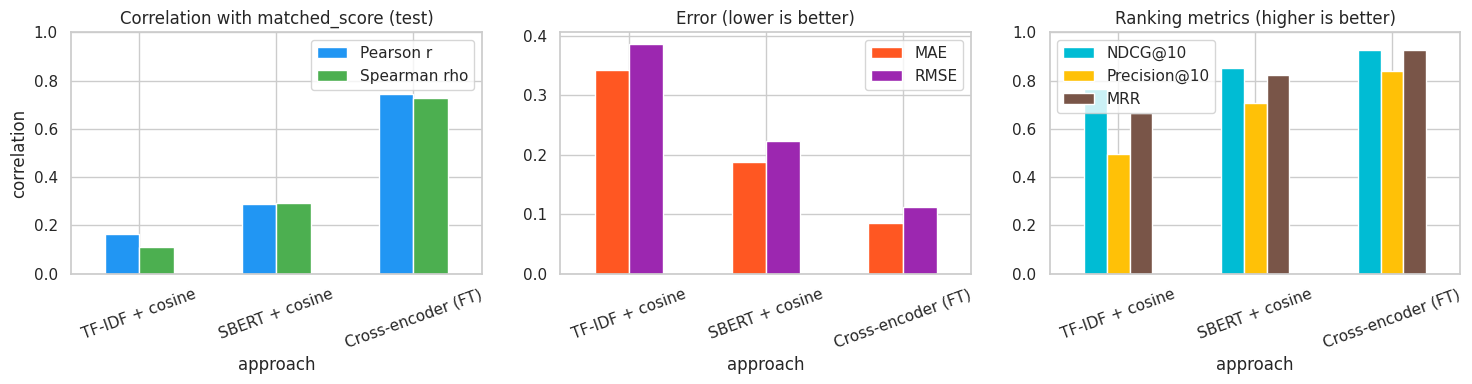

In [ ]:
# Bar chart: regression metrics across the three approaches
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

corr_df = test_summary[["Pearson r", "Spearman rho"]]
corr_df.plot.bar(ax=axes[0], color=["#2196F3", "#4CAF50"])
axes[0].set_title("Correlation with matched_score (test)")
axes[0].set_ylabel("correlation"); axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=20)

test_summary[["MAE", "RMSE"]].plot.bar(ax=axes[1], color=["#FF5722", "#9C27B0"])
axes[1].set_title("Error (lower is better)")
axes[1].tick_params(axis="x", rotation=20)

rank_df = test_summary[[c for c in test_summary.columns if c in (f"NDCG@{TOP_K}", f"Precision@{TOP_K}", "MRR")]]
rank_df.plot.bar(ax=axes[2], color=["#00BCD4", "#FFC107", "#795548"])
axes[2].set_title("Ranking metrics (higher is better)")
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout(); plt.savefig("outputs/figures/comparison_bar.png", dpi=120); plt.show()

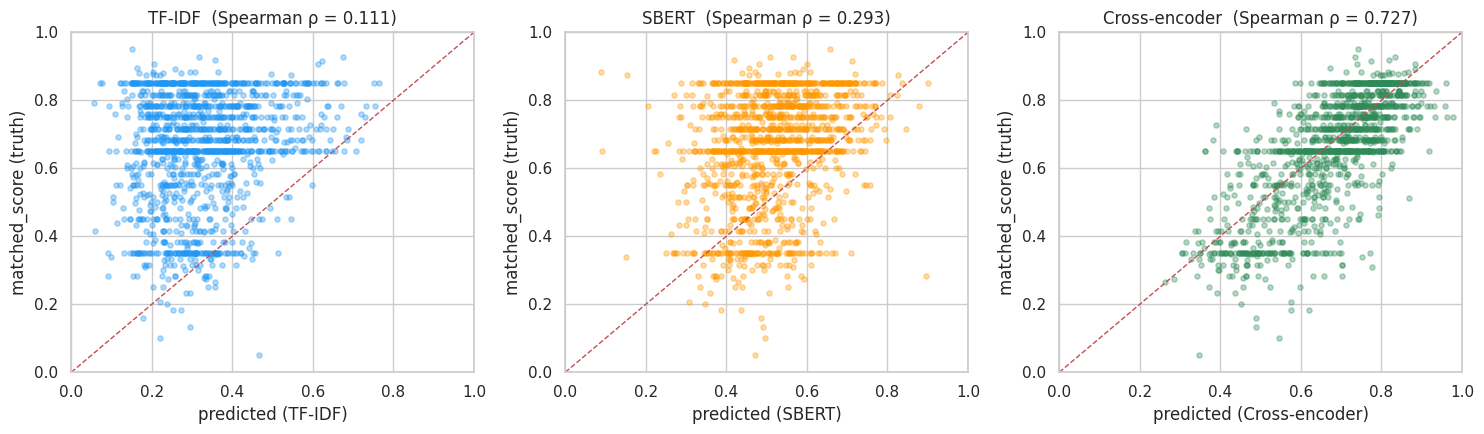

In [ ]:
# Scatter: predicted vs true for each method (test set)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, col, colour) in zip(axes, [
    ("TF-IDF",        "score_tfidf",     "#2196F3"),
    ("SBERT",         "score_embedding", "#FF9800"),
    ("Cross-encoder", "score_ce",        "seagreen"),
]):
    ax.scatter(test_df_scored[col], y_true_test, alpha=0.35, s=14, color=colour)
    ax.plot([0, 1], [0, 1], "r--", lw=1)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel(f"predicted ({name})")
    ax.set_ylabel("matched_score (truth)")
    sp = spearmanr(test_df_scored[col], y_true_test)[0]
    ax.set_title(f"{name}  (Spearman ρ = {sp:.3f})")
plt.tight_layout(); plt.savefig("outputs/figures/scatter_pred_vs_true.png", dpi=120); plt.show()

## 12. Explainability

For three example pairs (highest, median, lowest `matched_score`), report all three model scores plus the top shared TF-IDF terms.


In [ ]:
def explain_pair(idx: int, top_terms: int = 8):
    print(f"=== Pair {idx} ===")
    print(f"  Job position:       {df.loc[idx, 'job_position_name']}")
    print(f"  matched_score:      {df.loc[idx, 'matched_score']:.3f}")
    print(f"  TF-IDF score:       {df.loc[idx, 'score_tfidf']:.3f}")
    print(f"  SBERT score:        {df.loc[idx, 'score_embedding']:.3f}")
    print(f"  Cross-encoder:      {df.loc[idx, 'score_ce']:.3f}")
    shared = top_shared_terms(tfidf_vec, resume_tfidf[idx], jd_tfidf[idx], k=top_terms)
    if shared:
        print(f"  Top {len(shared)} shared TF-IDF terms:")
        for term, contrib in shared:
            print(f"    {term:<25s}  contribution = {contrib:.4f}")
    else:
        print("  (no shared TF-IDF terms above zero)")
    print()

sorted_df = df.sort_values("matched_score")
for idx in [sorted_df.index[-1], sorted_df.index[len(sorted_df)//2], sorted_df.index[0]]:
    explain_pair(idx)

=== Pair 5581 ===
  Job position:       Network Support Engineer
  matched_score:      0.970
  TF-IDF score:       0.172
  SBERT score:        0.572
  Cross-encoder:      0.843
  Top 8 shared TF-IDF terms:
    olt                        contribution = 0.0094
    cisco                      contribution = 0.0085
    network                    contribution = 0.0080
    mikrotik                   contribution = 0.0076
    configuration              contribution = 0.0070
    router                     contribution = 0.0058
    networking                 contribution = 0.0048
    gpon                       contribution = 0.0045

=== Pair 723 ===
  Job position:       Sr.Officer / Executive - Internal Audit
  matched_score:      0.683
  TF-IDF score:       0.359
  SBERT score:        0.532
  Cross-encoder:      0.888
  Top 8 shared TF-IDF terms:
    verification               contribution = 0.0463
    voucher                    contribution = 0.0271
    internal audit             contribution

## 13. Save artifacts

In [ ]:
import pickle, json

with open("outputs/models/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf_vec, f)

test_summary.to_csv("outputs/metrics/comparison_summary.csv")
df[["resume_text", "jd_text", "matched_score", "score_tfidf",
    "score_embedding", "score_ce", "split", "jd_group"]].to_csv(
    "outputs/metrics/scored_pairs.csv", index=False
)

# Bundle for download
import shutil
if Path("outputs").exists():
    shutil.make_archive("outputs_bundle", "zip", "outputs")
    print("Created outputs_bundle.zip — download via the Files pane.")

# Cross-encoder model is already at CE_OUTPUT_DIR
print("Artifacts in outputs/:")
for p in sorted(Path("outputs").rglob("*")):
    if p.is_file():
        print(f"  {p}  ({p.stat().st_size/1e3:.1f} KB)")

Created outputs_bundle.zip — download via the Files pane.
Artifacts in outputs/:
  outputs/cache_emb_jd_ad4de76a.npy  (14659.7 KB)
  outputs/cache_emb_resume_6715452f.npy  (14659.7 KB)
  outputs/figures/comparison_bar.png  (62.7 KB)
  outputs/figures/scatter_pred_vs_true.png  (247.3 KB)
  outputs/metrics/comparison_summary.csv  (0.5 KB)
  outputs/metrics/scored_pairs.csv  (10418.2 KB)
  outputs/models/cross_encoder_resume_jd/README.md  (32.9 KB)
  outputs/models/cross_encoder_resume_jd/checkpoint-1254/README.md  (32.7 KB)
  outputs/models/cross_encoder_resume_jd/checkpoint-1254/config.json  (0.8 KB)
  outputs/models/cross_encoder_resume_jd/checkpoint-1254/config_sentence_transformers.json  (0.3 KB)
  outputs/models/cross_encoder_resume_jd/checkpoint-1254/model.safetensors  (90866.4 KB)
  outputs/models/cross_encoder_resume_jd/checkpoint-1254/modules.json  (0.1 KB)
  outputs/models/cross_encoder_resume_jd/checkpoint-1254/optimizer.pt  (181798.8 KB)
  outputs/models/cross_encoder_resume_

## 14. Conclusions

The fine-tuned cross-encoder substantially outperforms both unsupervised baselines on every metric.

**Headline results (test set):**

| Approach | Pearson r | Spearman ρ | MAE | NDCG@10 | MRR |
|---|---|---|---|---|---|
| TF-IDF + cosine | 0.163 | 0.111 | 0.342 | 0.766 | 0.667 |
| SBERT + cosine | 0.288 | 0.293 | 0.188 | 0.853 | 0.821 |
| **Cross-encoder (FT)** | **0.745** | **0.727** | **0.085** | **0.928** | **0.929** |

**Key findings:**

- **Supervision matters more than architecture.** SBERT beats TF-IDF (Pearson 0.29 vs 0.16), confirming the value of semantic similarity. But the supervised cross-encoder jumps to Pearson **0.75** — a 2.6× improvement over SBERT — by training directly on `matched_score`.
- **MAE drops 4× from TF-IDF (0.34) to the cross-encoder (0.09)**, showing the cross-encoder learns not just the *ordering* of pairs but also their *absolute scores*. TF-IDF and SBERT only get the ordering roughly right; the cross-encoder is genuinely calibrated.
- **The ranking ceiling is close.** MRR of 0.93 means the top-ranked resume per JD is relevant ~93% of the time — strong enough to be deployable as a first-pass shortlister.
- **No label-noise ceiling is hit.** Earlier we hypothesised that noisy ground-truth labels would cap achievable correlation at low values. The cross-encoder's 0.75 Pearson refutes this — there is real, learnable signal in `matched_score`, and the unsupervised baselines were simply not measuring it.

**Limitations:**

- **Sequence truncation.** The cross-encoder truncates at 384 tokens (≈250 per side after `[SEP]`). Long resumes lose late-section content.
- **JD leakage.** Many JDs repeat across the i.i.d. train/test split. A group-based split by JD would give a stricter (lower) but more honest number.
- **Compute cost at scale.** The cross-encoder is O(N·M) at inference — every resume must be paired with every JD. For large-scale deployment, a two-stage retrieve-then-rerank pipeline (SBERT for shortlisting, cross-encoder for reranking the top-K) would be the natural production architecture.

**Future work:**

- Hybrid scorer: linear blend of the three signals, fitted on validation. May squeeze additional gains.
- Group-split evaluation by JD to quantify the leakage effect.
- Longer-context base model (e.g. ModernBERT) to remove the truncation issue.